# 실습 6: 다중 페이지 PDF 처리 파이프라인
**소요시간: 40분** | 난이도: ⭐⭐⭐⭐

## 학습 목표
1. 다중 페이지 PDF를 **페이지별 이미지**로 변환합니다.
2. 각 페이지를 `analyze_document`로 처리하고 결과를 통합합니다.
3. 페이지별 텍스트, 폼, 표 데이터를 추출하는 파이프라인을 구현합니다.

## 처리 흐름
```
로컬 PDF → [pdf2image] → 페이지별 PNG
         → [Textract analyze_document] → 페이지별 Block
         → [파싱] → 텍스트 / 폼 / 표
         → [저장] → JSON / CSV
```

## API 개요: analyze_document
```python
response = textract.analyze_document(
    Document={'Bytes': <바이트>},
    FeatureTypes=['FORMS', 'TABLES']  # 분석 기능 선택
)
```

### Block 구조
```
PAGE
├── LINE → WORD                          (텍스트)
├── KEY_VALUE_SET(KEY) → VALUE → WORD    (폼)
└── TABLE → CELL → WORD                 (표)
```

> 💡 S3 비동기 방식(`start_document_analysis`)은 대용량 PDF(10MB+, 3000페이지)에 적합합니다.
> 이번 실습의 로컬 동기 방식은 소규모 PDF에 적합하며 S3 권한 없이 실습 가능합니다.


In [1]:
# ✅ [제공 코드] 라이브러리 설치 및 poppler 확인
import sys
!{sys.executable} -m pip install pdf2image pillow --quiet

import subprocess
r = subprocess.run(['which', 'pdftoppm'], capture_output=True, text=True)
if r.returncode == 0:
    print('poppler OK:', r.stdout.strip())
else:
    print('poppler 미설치. 아래 중 해당하는 명령 실행:')
    print('  Linux : !sudo apt-get install -y poppler-utils')
    print('  macOS : !brew install poppler')


poppler OK: /opt/conda/bin/pdftoppm


In [2]:
# ✅ [제공 코드] 환경 초기화
import boto3, os, json, time
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
from pdf2image import convert_from_path
from collections import Counter

textract = boto3.client('textract', region_name='ap-northeast-2')
PDF_PATH = './images/lab06_async.pdf'
OUTPUT_DIR = './lab06_pages/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('환경 설정 완료')
print(f'  PDF: {PDF_PATH}')
print(f'  출력 디렉토리: {OUTPUT_DIR}')


환경 설정 완료
  PDF: ./images/lab06_async.pdf
  출력 디렉토리: ./lab06_pages/


## ✏️ TODO 1: PDF → 페이지별 이미지 변환

`convert_from_path()`로 PDF를 페이지별 PNG 이미지로 변환하는 함수를 완성하세요.


In [3]:
# ✏️ TODO 1: pdf_to_images() 함수를 완성하세요
def pdf_to_images(pdf_path, output_dir, dpi=200):
    print(f'PDF 변환 중: {pdf_path}')

    pages = convert_from_path(pdf_path, dpi=dpi)  # ← convert_from_path
    print(f'  총 {len(pages)}페이지')

    image_paths = []
    for i, page in enumerate(pages, start=1):
        img_path = os.path.join(output_dir, f'page_{i:03d}.png')
        page.save(img_path, 'PNG')
        size = os.path.getsize(img_path)
        print(f'  페이지 {i}: {img_path} ({size:,} bytes)')
        image_paths.append(img_path) # ← img_path

    return image_paths

image_paths = pdf_to_images(PDF_PATH, OUTPUT_DIR)
print(f'완료: {len(image_paths)}개 이미지')


PDF 변환 중: ./images/lab06_async.pdf


  총 2페이지
  페이지 1: ./lab06_pages/page_001.png (472,767 bytes)


  페이지 2: ./lab06_pages/page_002.png (49,491 bytes)
완료: 2개 이미지


/tmp/ipykernel_1856/1537203318.py:11: UserWarning: Glyph 54168 (\N{HANGUL SYLLABLE PE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1856/1537203318.py:11: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1856/1537203318.py:11: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1856/1537203318.py:11: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1856/1537203318.py:11: UserWarning: Glyph 54872 (\N{HANGUL SYLLABLE HWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1856/1537203318.py:11: UserWarning: Glyph 46108 (\N{HANGUL SYLLABLE DOEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1856/1537203318.py:11: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_la

/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54168 (\N{HANGUL SYLLABLE PE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54872 (\N{HANGUL SYLLABLE HWAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46108 (\N{HANGUL SYLLABLE DOEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/op

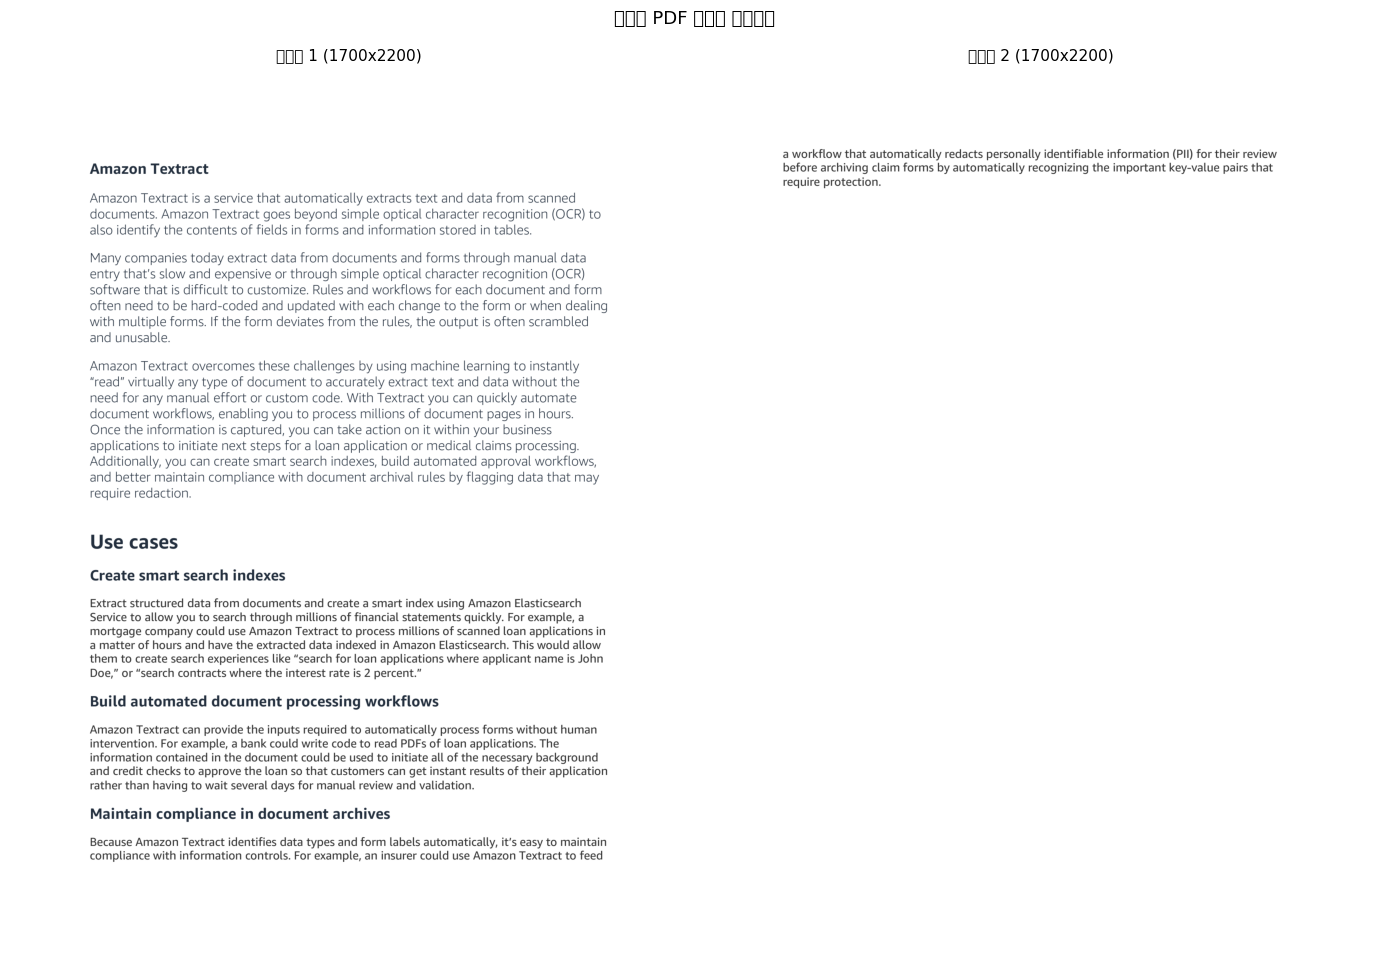

In [4]:
# ✅ [제공 코드] 변환된 페이지 미리보기
n = len(image_paths)
fig, axes = plt.subplots(1, n, figsize=(7*n, 10))
if n == 1: axes = [axes]
for i, (ax, path) in enumerate(zip(axes, image_paths)):
    img = Image.open(path)
    ax.imshow(img)
    ax.set_title(f'페이지 {i+1} ({img.size[0]}x{img.size[1]})', fontsize=11)
    ax.axis('off')
plt.suptitle('변환된 PDF 페이지 미리보기', fontsize=13)
plt.tight_layout()
plt.show()


## ✏️ TODO 2: 단일 페이지 analyze_document 호출

각 페이지 이미지를 바이트로 읽어 Textract `analyze_document`에 전달하는 함수를 완성하세요.


In [5]:
# ✏️ TODO 2: analyze_page() 함수를 완성하세요
def analyze_page(image_path, page_num):
    with open(image_path, 'rb') as f:
        img_bytes = f.read()

    print(f'  페이지 {page_num} 분석 중...', end=' ')

    response = textract.analyze_document(
        Document={'Bytes': img_bytes},     # ← img_bytes
        FeatureTypes=['FORMS', 'TABLES']    # ← 'FORMS', 'TABLES'
    )

    blocks = response['Blocks']
    block_map = {b['Id']: b for b in blocks}
    counts = Counter(b['BlockType'] for b in blocks)
    summary = ', '.join(f'{k}:{v}' for k, v in sorted(counts.items()))
    print(f'완료 ({len(blocks)}블록 [{summary}])')

    return {'page': page_num, 'blocks': blocks, 'block_map': block_map}

print('✅ analyze_page() 함수 준비 완료')


✅ analyze_page() 함수 준비 완료


## ✏️ TODO 3: 전체 페이지 순차 처리

모든 페이지를 순서대로 처리하고 API 호출 간격을 두는 파이프라인 함수를 완성하세요.


In [6]:
# ✏️ TODO 3: process_all_pages() 함수를 완성하세요
def process_all_pages(image_paths, delay=0.5):
    all_results = []
    print(f'총 {len(image_paths)}페이지 처리 시작')
    print('-' * 40)

    for i, img_path in enumerate(image_paths):
        result = analyze_page(img_path, i + 1)  # ← analyze_page
        all_results.append(result)

        if i < len(image_paths) - 1:
            time.sleep(delay)  # ← delay

    print(f'전체 {len(all_results)}페이지 처리 완료')
    return all_results

all_results = process_all_pages(image_paths)


총 2페이지 처리 시작
----------------------------------------
  페이지 1 분석 중... 

완료 (457블록 [KEY_VALUE_SET:6, LINE:36, PAGE:1, WORD:414])


  페이지 2 분석 중... 

완료 (32블록 [KEY_VALUE_SET:2, LINE:3, PAGE:1, WORD:26])
전체 2페이지 처리 완료


## ✏️ TODO 4: 페이지별 텍스트(LINE) 추출

Textract Block 중 `LINE` 타입만 필터링하여 페이지별 텍스트를 추출하세요.


In [7]:
# ✅ [제공 코드] Block에서 텍스트를 추출하는 헬퍼 함수
def get_text_from_block(block, block_map):
    """Block의 CHILD 관계에 있는 WORD들을 모아 텍스트 반환"""
    text = ''
    for rel in block.get('Relationships', []):
        if rel['Type'] == 'CHILD':
            for cid in rel['Ids']:
                child = block_map.get(cid, {})
                if child.get('BlockType') == 'WORD':
                    text += child.get('Text', '') + ' '
    return text.strip()

print('✅ get_text_from_block() 함수 준비 완료')


✅ get_text_from_block() 함수 준비 완료


In [8]:
# ✏️ TODO 4: 각 페이지에서 LINE 텍스트를 추출하는 함수를 완성하세요
def extract_text_by_page(all_results):
    page_texts = {}
    for result in all_results:
        page_num = result['page']
        lines = [
            b.get('Text', '')
            for b in result['blocks']
            if b['BlockType'] == 'LINE'  # ← 'BlockType', 'LINE'
        ]
        page_texts[page_num] = lines
    return page_texts

page_texts = extract_text_by_page(all_results)
print('페이지별 텍스트:')
for pn, lines in page_texts.items():
    print(f'  페이지 {pn}: {len(lines)}줄')
    for line in lines[:5]:
        print(f'    {line}')


페이지별 텍스트:
  페이지 1: 36줄
    Amazon Textract
    Amazon Textract is a service that automatically extracts text and data from scanned
    documents. Amazon Textract goes beyond simple optical character recognition (OCR) to
    also identify the contents of fields in forms and information stored in tables.
    Many companies today extract data from documents and forms through manual data
  페이지 2: 3줄
    a workflow that automatically redacts personally identifiable information (PII) for their review
    before archiving claim forms by automatically recognizing the important key-value pairs that
    require protection.


## ✏️ TODO 5: 페이지별 폼(Key-Value) 추출

`KEY_VALUE_SET` 블록에서 Key와 Value를 연결하여 페이지별 폼 데이터를 추출하세요.


In [10]:
# ✏️ TODO 5: KEY_VALUE_SET 블록을 파싱하는 함수를 완성하세요
def extract_forms_by_page(all_results):
    page_forms = {}
    for result in all_results:
        page_num = result['page']
        blocks = result['blocks']
        block_map = result['block_map']
        forms = {}

        key_blocks = [
            b for b in blocks
            if b['BlockType'] == 'KEY_VALUE_SET'
            and 'KEY' in b.get('EntityTypes', [])  # ← 'KEY'
        ]
        for key_block in key_blocks:
            key_text = get_text_from_block(key_block, block_map)
            value_text = ''
            for rel in key_block.get('Relationships', []):
                if rel['Type'] == 'VALUE':  # ← 'Type', 'VALUE'
                    for vid in rel['Ids']:  # ← 'Ids'
                        vb = block_map.get(vid)
                        if vb:
                            value_text = get_text_from_block(vb, block_map)  # ← vb
            if key_text:
                forms[key_text] = value_text
        page_forms[page_num] = forms
    return page_forms

page_forms = extract_forms_by_page(all_results)
for pn, forms in page_forms.items():
    print(f'페이지 {pn}: {len(forms)}개 Key-Value')
    for k, v in list(forms.items())[:4]:
        print(f'  {k:<30}: {v}')


페이지 1: 3개 Key-Value
  Maintain compliance in document archives: Because Amazon Textract identifies data types and form labels automatically, it's easy to maintain compliance with information controls. For example, an insurer could use Amazon Textract to feed
  Build automated document processing workflows: Amazon Textract can provide the inputs required to automatically process forms without human intervention. For example, a bank could write code to read PDFs of loan applications. The information contained in the document could be used to initiate all of the necessary background and credit checks to approve the loan so that customers can get instant results of their application rather than having to wait several days for manual review and validation.
  Create smart search indexes   : Extract structured data from documents and create a smart index using Amazon Elasticsearch Service to allow you to search through millions of financial statements quickly. For example, a mortgage company 

## ✏️ TODO 6: 페이지별 표(TABLE) → DataFrame 변환

`TABLE` 블록을 파싱하여 pandas DataFrame으로 변환하는 함수를 완성하세요.


In [12]:
# ✏️ TODO 6: TABLE 블록을 DataFrame으로 변환하는 함수를 완성하세요
def extract_tables_by_page(all_results):
    page_tables = {}
    for result in all_results:
        page_num = result['page']
        blocks = result['blocks']
        block_map = result['block_map']
        dfs = []

        table_blocks = [b for b in blocks if b['BlockType'] == 'TABLE']  # ← 'BlockType', 'TABLE'

        for tb in table_blocks:
            rows = {}
            for rel in tb.get('Relationships', []):
                if rel['Type'] == 'CHILD':  # ← 'Type'
                    for cid in rel['Ids']:  # ← 'Ids'
                        cell = block_map.get(cid)
                        if cell and cell['BlockType'] == 'CELL':
                            r = cell['RowIndex']  # ← 'RowIndex'
                            c = cell['ColumnIndex']  # ← 'ColumnIndex'
                            rows.setdefault(r, {})[c] = get_text_from_block(cell, block_map)
            if rows:
                max_r = max(rows.keys())
                max_c = max(max(row.keys()) for row in rows.values())
                data = [[rows.get(r, {}).get(c, '') for c in range(1, max_c+1)]
                        for r in range(1, max_r+1)]
                df = pd.DataFrame(data)
                if not df.empty:
                    df.columns = df.iloc[0]
                    df = df[1:].reset_index(drop=True)
                    dfs.append(df)
        page_tables[page_num] = dfs
    return page_tables

page_tables = extract_tables_by_page(all_results)
for pn, dfs in page_tables.items():
    print(f'페이지 {pn}: {len(dfs)}개 표')
    for i, df in enumerate(dfs):
        print(f'  표 #{i+1} ({df.shape[0]}행 x {df.shape[1]}열)')
        print(df.head(3).to_string())


페이지 1: 0개 표
페이지 2: 0개 표


## ✏️ TODO 7: 전체 결과 저장

추출한 텍스트, 폼 데이터를 JSON으로, 표 데이터를 CSV로 저장하세요.


In [14]:
# ✏️ TODO 7: 결과를 파일로 저장하세요
out = './lab06_output/'
os.makedirs(out, exist_ok=True)

# 텍스트 → JSON 저장
with open(os.path.join(out, 'all_text.json'), 'w') as f:    # ← 'w'
    json.dump(page_texts, f, ensure_ascii=False, indent=2)          # ← page_texts
print('✅ all_text.json 저장 완료')

# 폼 → JSON 저장
with open(os.path.join(out, 'all_forms.json'), 'w') as f:
    json.dump(page_forms, f, ensure_ascii=False, indent=2)          # ← page_forms
print('✅ all_forms.json 저장 완료')

# 표 → CSV 저장
csv_count = 0
for pn, dfs in page_tables.items():
    for i, df in enumerate(dfs):
        filename = f'page{pn}_table{i+1}.csv'
        df.to_csv(os.path.join(out, filename), index=False, encoding='utf-8-sig')  # ← filename
        csv_count += 1
print(f'✅ 표 CSV {csv_count}개 저장 완료')

print(f'\n결과 저장 위치: {out}')
for fname in sorted(os.listdir(out)):
    size = os.path.getsize(os.path.join(out, fname))
    print(f'  {fname:<35} {size:>8,} bytes')


✅ all_text.json 저장 완료
✅ all_forms.json 저장 완료
✅ 표 CSV 0개 저장 완료

결과 저장 위치: ./lab06_output/
  all_forms.json                         1,589 bytes
  all_text.json                          3,231 bytes


## 💡 심화 도전
1. 처리 시간을 페이지별로 측정하여 비교해보세요.
2. 여러 페이지에 걸친 동일 Key의 Value를 병합하는 로직을 만들어보세요.
3. 로컬 동기 방식과 S3 비동기 방식의 장단점을 비교해보세요.

| 비교 항목 | 로컬 동기 (이번 실습) | S3 비동기 |
|---|---|---|
| 파일 크기 제한 | 10MB 이하 | 500MB 이하 |
| 페이지 제한 | 1페이지/호출 | 최대 3,000페이지 |
| S3 필요 여부 | 불필요 | 필요 |
| 처리 방식 | 페이지별 직렬 | 전체 병렬 |
| 적합한 상황 | 소규모 테스트 | 대규모 프로덕션 |
